# Protein Model Evaluation and Comparison

This notebook provides a step-by-step evaluation and comparison of two trained protein prediction models. The workflow includes loading models, preparing data, optimizing thresholds, evaluating performance on residue and domain levels, and analyzing confusion patterns between protein families.

**Outline:**
1. Import Required Libraries
2. Load Trained Models
3. Load and Prepare Datasets
4. Obtain Model Predictions and Probabilities (Softmax)
5. Find Optimal Threshold on Train & Validation Sets
6. Evaluate Per-Class Metrics (Accuracy, Precision, Recall, F1)
7. Test Set Evaluation: Predictions and Metrics
8. Measure Inference Runtime and GPU Usage
9. Calculate Model Size (Number of Parameters)
10. Compute Confusion Matrix for Residue-Level Predictions
11. Domain-Level Prediction Evaluation
12. Analyze Confusion Patterns Between Protein Families

### Changes in this notebook

- scatter plot f1 vs. support for both models
- rerun for 0.5 ce, expected higher macro f1 and lower accuracy, class 0 f1 lower, but rest higher
- why not 60% seq id instead of 30%
- residual per class percentage vs background
- look into macro f1
- how are fams distributed across clusters? how to plot this?

- also important question: what does precision and recall mean in our case?

## 1. Import Required Libraries
Import all necessary libraries for data handling, model loading, evaluation, and visualization.

In [1]:
# Standard libraries
import os
import sys
import time
import tracemalloc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset

# Sklearn metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Custom imports (adjust paths as needed)
sys.path.append(os.path.abspath('../models'))
from Dataset import ProteinCSVWindowDataset, ProteinEmbeddingWithLabelsDataset,  collate_fn_window
from models.original import OriginalModel, OriginalModelLarger
from models.small import SmallModel

random.seed(42)

## 2. Load Trained Models
Load both final trained models from their .pth files and set them to evaluation mode.

In [2]:
# Specify path to correct model
# emb_path = './checkpoints/original_bs8_lr3e-04_ep15_20250623_232208.pth'  # EMB # this is the one with standard weights
emb_path = './checkpoints/original_bs8_lr1e-03_ep15_20250623_182218.pth'  # EMB # this is 0.5 ce weights
# onehot_path = './checkpoints/original_bs8_lr3e-03_ep15_20250622_212924.pth'     # onehot # this is the one with standard weights
onehot_path = './checkpoints/original_bs1_lr1e-05_ep15_20250622_011338.pth'     # onehot # this is 0.5 ce weights

# flag for exporting plots and data
export = False

In [3]:
# Instantiate models

model_emb = OriginalModel(num_classes=58, channels=512, input_size=1024)
model_oh = OriginalModel(num_classes=58, channels=512)

# Load weights
model_oh.load_state_dict(torch.load(onehot_path, map_location='cuda'))
model_emb.load_state_dict(torch.load(emb_path, map_location='cuda'))

# Set to evaluation mode
model_oh.eval()
model_emb.eval()

OriginalModel(
  (input_layer): Sequential(
    (0): Conv1d(1024, 512, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, trac

## 3. Load and Prepare Datasets
Load train, validation, and test datasets from CSV files. Prepare DataLoader objects for each split.

### OneHot Data

In [4]:
# File paths
general_path = ""
TRAIN_CSV = f'{general_path}train.csv'
VAL_CSV = f'{general_path}val.csv'
TEST_CSV = f'{general_path}test.csv'

# Create datasets
train_dataset_oh = ProteinCSVWindowDataset(TRAIN_CSV)
val_dataset_oh = ProteinCSVWindowDataset(VAL_CSV)
test_dataset_oh = ProteinCSVWindowDataset(TEST_CSV)

# Create dataloaders
BATCH_SIZE = 32
train_loader_oh = DataLoader(train_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
val_loader_oh = DataLoader(val_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
test_loader_oh = DataLoader(test_dataset_oh, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

In [5]:
# fix the labels: cut off the start and end of the sequence
import re

# label includes the start and end of the sequence -> cut off to get actual label
def cut_off_start_end(label: str) -> str:
    return re.sub(r'-.*', '', label)

train_dataset_oh.df['label'] = train_dataset_oh.df['label'].apply(cut_off_start_end)
val_dataset_oh.df['label'] = val_dataset_oh.df['label'].apply(cut_off_start_end)
test_dataset_oh.df['label'] = test_dataset_oh.df['label'].apply(cut_off_start_end)

### Embedding Data

In [6]:
# File paths
general_path = r"E:\Data\embeddings41k"

TRAIN_CSV = f"{general_path}/train/all_embeddings_and_labels.h5"
VAL_CSV = f"{general_path}/val/all_embeddings_and_labels.h5"
TEST_CSV = f"{general_path}/test/all_embeddings_and_labels.h5"

# Create datasets
train_dataset_emb = ProteinEmbeddingWithLabelsDataset(TRAIN_CSV)
val_dataset_emb = ProteinEmbeddingWithLabelsDataset(VAL_CSV)
test_dataset_emb = ProteinEmbeddingWithLabelsDataset(TEST_CSV)

# Create dataloaders
BATCH_SIZE = 32
train_loader_emb = DataLoader(train_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
val_loader_emb = DataLoader(val_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
test_loader_emb = DataLoader(test_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)

#### Set output directory for plots, checkpoints, etc.

Remember to change this for different runs!!!

In [7]:
OUTPUT_DIR = "./output_rerun_ce_0.5" 

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

## Plot seq length distr colored by train / val / test 

In [8]:
# Add a column to each split to indicate the split
train_df = train_dataset_oh.df.copy()
train_df['split'] = 'train'
val_df = val_dataset_oh.df.copy()
val_df['split'] = 'val'
test_df = test_dataset_oh.df.copy()
test_df['split'] = 'test'

# Concatenate all splits
all_oh_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(all_oh_df.shape)

# Get unique proteins per split (avoid double-counting proteins)
unique_oh_df = all_oh_df.drop_duplicates(subset='AC')
print(unique_oh_df.shape)

# Prepare lengths per split
lengths_train = unique_oh_df[unique_oh_df['split'] == 'train']['length'].values
lengths_val = unique_oh_df[unique_oh_df['split'] == 'val']['length'].values
lengths_test = unique_oh_df[unique_oh_df['split'] == 'test']['length'].values

(41646, 11)
(41646, 11)


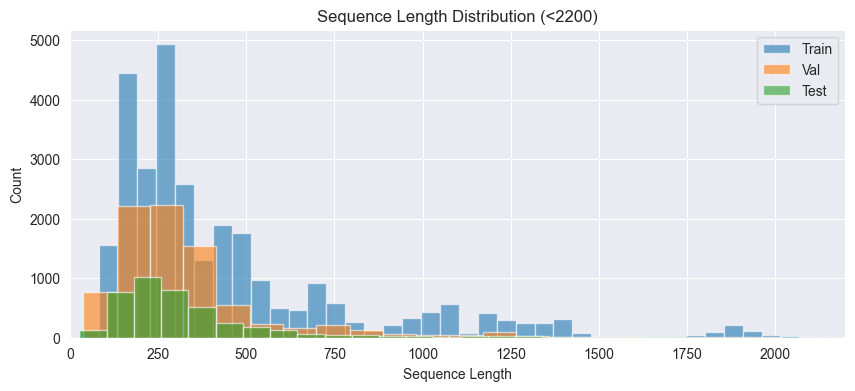

In [9]:
plt.figure(figsize=(10,4))
plt.hist(lengths_train, bins=50, alpha=0.6, label='Train')
plt.hist(lengths_val, bins=50, alpha=0.6, label='Val')
plt.hist(lengths_test, bins=50, alpha=0.6, label='Test')
#plt.xscale('log') 
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Sequence Length Distribution (<2200)')
plt.legend()
plt.xlim(0, 2200) 
if export:
    plt.savefig(os.path.join(OUTPUT_DIR, 'seq_length_distribution_st_2200_oh.png'))
plt.show()

Min length: 26, Max length  4760


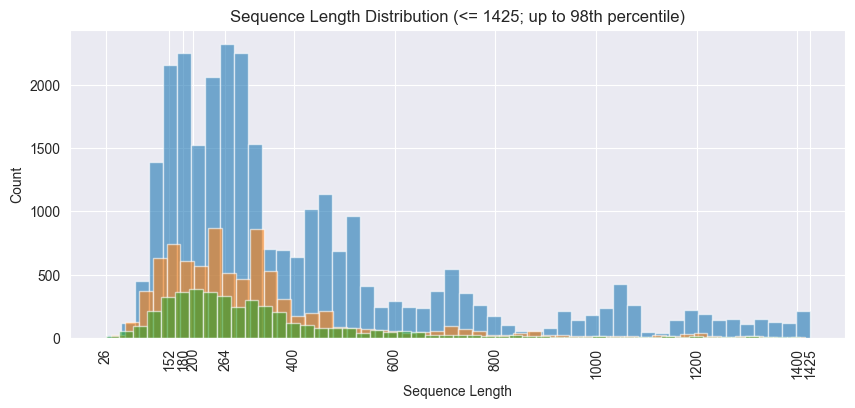

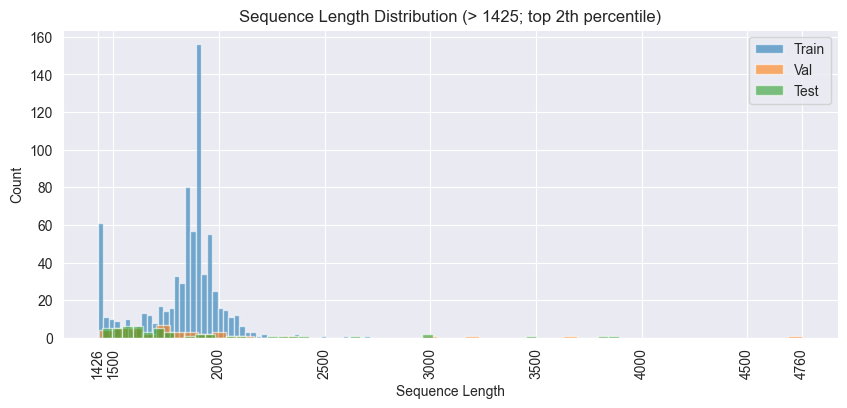

In [10]:
q = 98 # Show up to 99th percentile
max_length = np.percentile(np.concatenate([lengths_train, lengths_val, lengths_test]), q)
min_length = min(np.concatenate([lengths_train, lengths_val, lengths_test]))
max_length_overall = max(np.concatenate([lengths_train, lengths_val, lengths_test]))
print(f"Min length: {min_length}, Max length  {max_length_overall}")
plt.figure(figsize=(10,4))
n_bins = 50
min_dist = 30

# Plot histograms
plt.hist(lengths_train[lengths_train <= max_length], bins=n_bins, alpha=0.6, label='Train')
plt.hist(lengths_val[lengths_val <= max_length], bins=n_bins, alpha=0.6, label='Val')
plt.hist(lengths_test[lengths_test <= max_length], bins=n_bins, alpha=0.6, label='Test')

# Add more xticks where distribution is high
counts, bin_edges = np.histogram(np.concatenate([
    lengths_train[lengths_train <= max_length],
    lengths_val[lengths_val <= max_length],
    lengths_test[lengths_test <= max_length]
]), bins=n_bins)
threshold = np.percentile(counts, 95)  # Top 5% bins
high_bins = np.where(counts >= threshold)[0]
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# Get current xticks and add new ones with minimum distance constraint
current_xticks = list(plt.xticks()[0])
new_ticks = list(bin_centers[high_bins])

# Filter ticks to maintain minimum distance
min_distance = (max_length - min_length) / 200  # Ensure reasonable spacing
all_ticks = current_xticks + new_ticks
all_ticks = [tick for tick in all_ticks if tick >= min_length and tick <= max_length]
all_ticks = sorted(set(np.round(all_ticks).astype(int)))

# Keep ticks that are sufficiently spaced apart
filtered_ticks = [all_ticks[0]] if all_ticks else []
for tick in all_ticks[1:]:
    if tick - filtered_ticks[-1] >= min_distance:
        filtered_ticks.append(tick)
# Only add min_length if far enough from nearest tick
if filtered_ticks:
    if all(abs(int(min_length) - t) >= min_distance for t in filtered_ticks):
        filtered_ticks = [int(min_length)] + filtered_ticks
    if all(abs(int(max_length) - t) >= min_distance for t in filtered_ticks):
        filtered_ticks.append(int(max_length))
plt.xticks(filtered_ticks, rotation=90)

plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title(f'Sequence Length Distribution (<= {int(max_length)}; up to {q}th percentile)')
if export:
    plt.savefig(os.path.join(OUTPUT_DIR, f'seq_length_distribution_le_{int(max_length)}_oh.png'))

# for the rest 100 - q % 
plt.figure(figsize=(10,4))
plt.hist(lengths_train[lengths_train > max_length], bins=50, alpha=0.6, label='Train')
plt.hist(lengths_val[lengths_val > max_length], bins=50, alpha=0.6, label='Val')
plt.hist(lengths_test[lengths_test > max_length], bins=50, alpha=0.6, label='Test')

# Add min and max length as ticks for the tail plot, but only if far enough from other ticks
current_xticks_tail = list(plt.xticks()[0])
min_tail = int(np.min(lengths_train[lengths_train > max_length].tolist() + lengths_val[lengths_val > max_length].tolist() + lengths_test[lengths_test > max_length].tolist() or [max_length+1]))
max_tail = int(max_length_overall)
filtered_ticks_tail = sorted(set([int(tick) for tick in current_xticks_tail if tick >= min_tail and tick <= max_tail]))
# Only add min_tail if far enough from nearest tick
if filtered_ticks_tail:
    if all(abs(int(min_tail) - t) >= min_distance for t in filtered_ticks_tail):
        filtered_ticks_tail = [int(min_tail)] + filtered_ticks_tail
    if all(abs(int(max_tail) - t) >= min_distance for t in filtered_ticks_tail):
        filtered_ticks_tail.append(int(max_tail))
else:
    filtered_ticks_tail = [int(min_tail), int(max_tail)]
plt.xticks(filtered_ticks_tail, rotation=90)

plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title(f'Sequence Length Distribution (> {int(max_length)}; top {100-q}th percentile)')
plt.legend()
if export:
    plt.savefig(os.path.join(OUTPUT_DIR, f'seq_length_distribution_gt_{int(max_length)}_oh.png'))
plt.show()

## Plot label / class  Venn Diagram colored by Train / Val / Test 

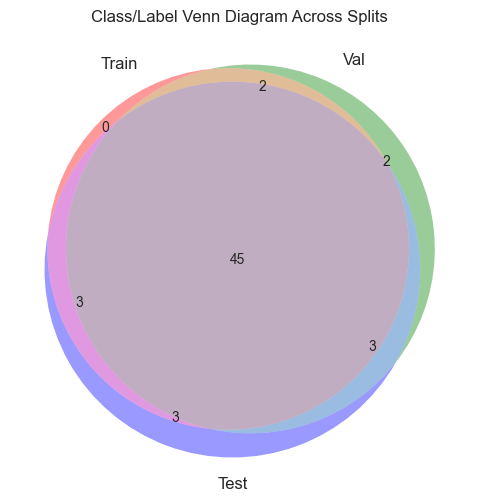

In [11]:
# Plot label / class distribution Venn Diagram colored by Train / Val / Test
from matplotlib_venn import venn3

# Get unique labels/classes in each split (residue-level)
labels_train = set(train_dataset_oh.df['label'])
labels_val = set(val_dataset_oh.df['label'])
labels_test = set(test_dataset_oh.df['label'])
plt.figure(figsize=(6,6))
venn3([labels_train, labels_val, labels_test], set_labels=('Train', 'Val', 'Test'))
plt.title("Class/Label Venn Diagram Across Splits")
if export:
    plt.savefig(os.path.join(OUTPUT_DIR, 'class_label_venn_oh.png'))
plt.show()

### extract the classes that are only in test set (for later analysis regarding predicitons)

In [12]:
labels_only_in_test = labels_test - labels_train - labels_val
print(f"Classes only in test set ({len(labels_only_in_test)}): {sorted(labels_only_in_test)}")

Classes only in test set (3): ['PF11330.14', 'PF17644.7', 'PF20758.2']


## Class distribution / frequency => to analyze for inbalance in dataset (how much more is class 0 present?)

In [13]:
all_oh_df.columns

Index(['AC', 'label', 'fam_id', 'fam_id_num', 'unique_fam_ids', 'start', 'end',
       'length', 'header', 'sequence', 'split'],
      dtype='object')

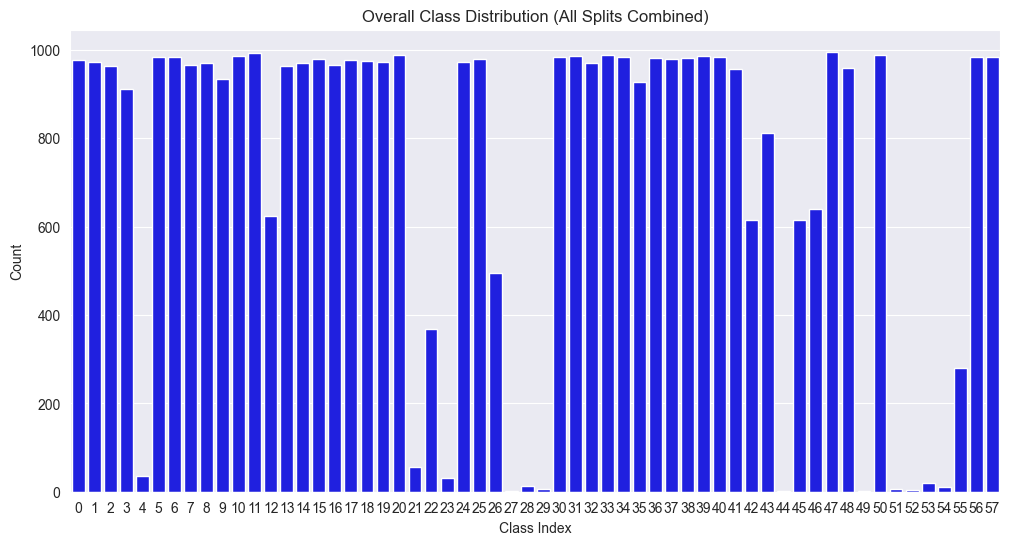

In [14]:
# Plot class distribution for all data 
plt.figure(figsize=(12,6))
sns.countplot(data=all_oh_df, x='label', order=sorted(all_oh_df['label'].unique()), color='blue')
plt.xlabel('Class Index')
plt.ylabel('Count')
plt.title('Overall Class Distribution (All Splits Combined)')
plt.xticks(ticks=range(len(sorted(all_oh_df['label'].unique()))), labels=range(len(sorted(all_oh_df['label'].unique()))))
if export:
    plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution_all_oh.png'))
plt.show()

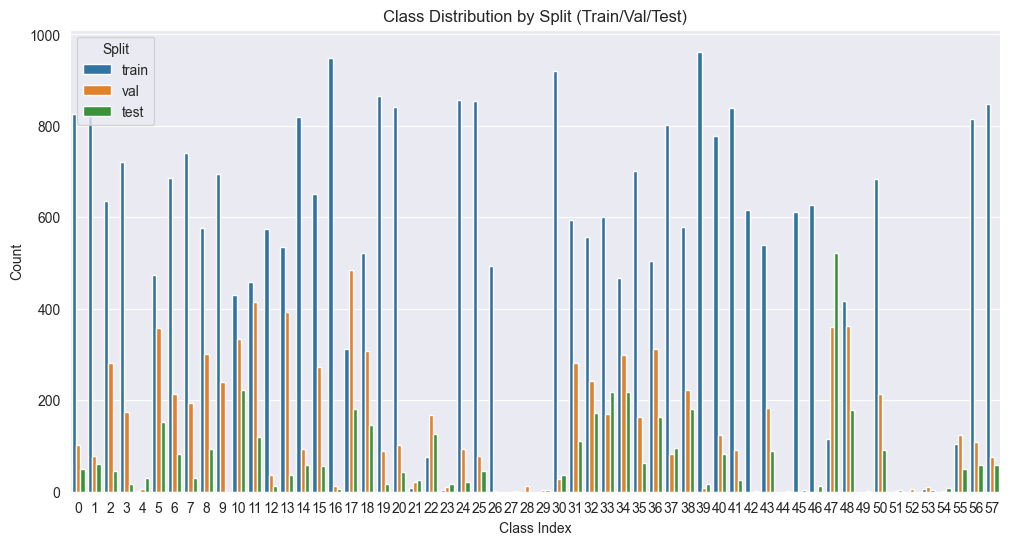

In [15]:

# Plot class distribution colored by split (train/val/test)
plt.figure(figsize=(12,6))
sns.countplot(data=all_oh_df, x='label', hue='split', order=sorted(all_oh_df['label'].unique()))
plt.xlabel('Class Index')
plt.ylabel('Count')
plt.title('Class Distribution by Split (Train/Val/Test)')
plt.legend(title='Split')
plt.xticks(ticks=range(len(sorted(all_oh_df['label'].unique()))), labels=range(len(sorted(all_oh_df['label'].unique()))))
if export:
    plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution_by_split_oh.png'))
plt.show()

C:\Users\danei\AppData\Local\Temp\ipykernel_31980\4009022884.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


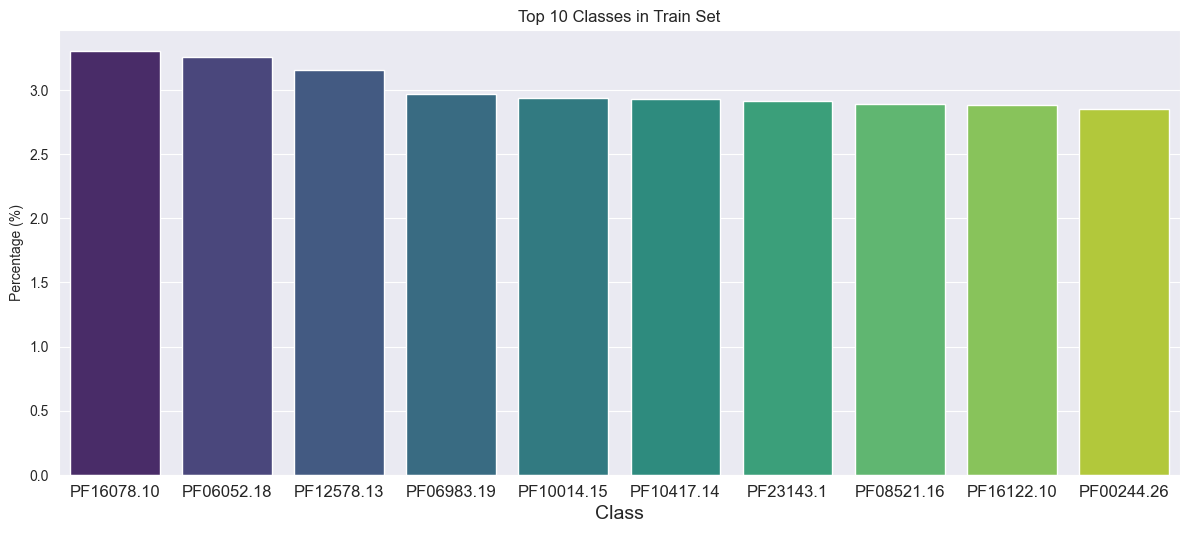

C:\Users\danei\AppData\Local\Temp\ipykernel_31980\4009022884.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


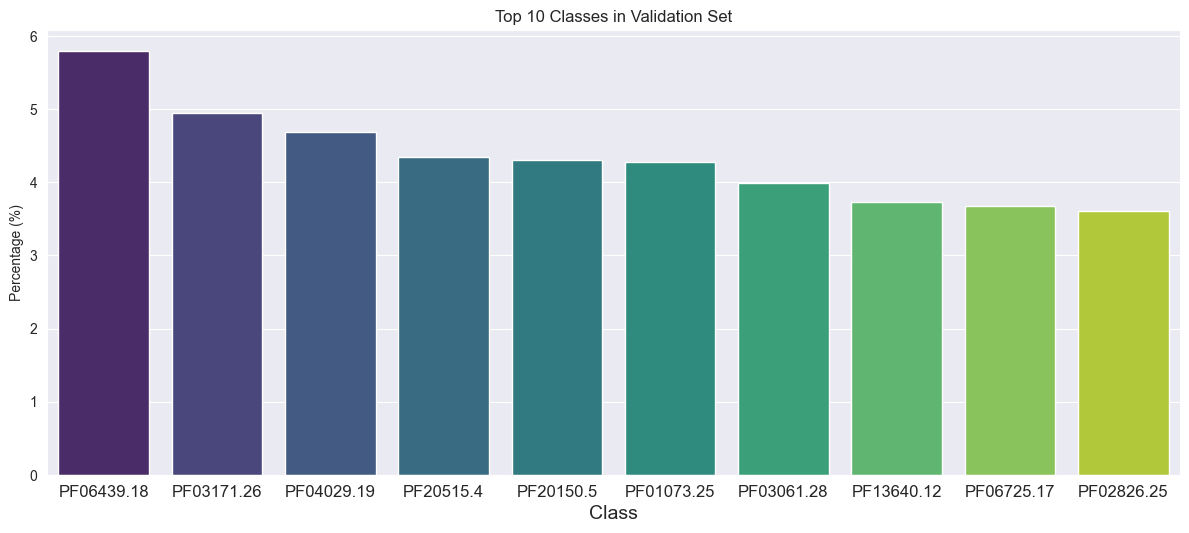

C:\Users\danei\AppData\Local\Temp\ipykernel_31980\4009022884.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


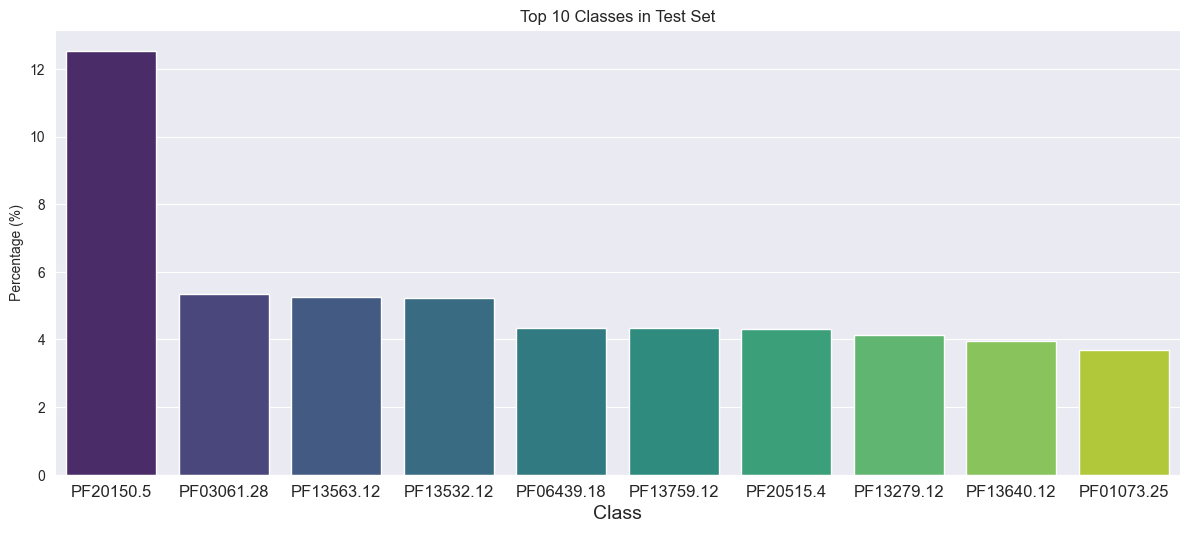

C:\Users\danei\AppData\Local\Temp\ipykernel_31980\4009022884.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')


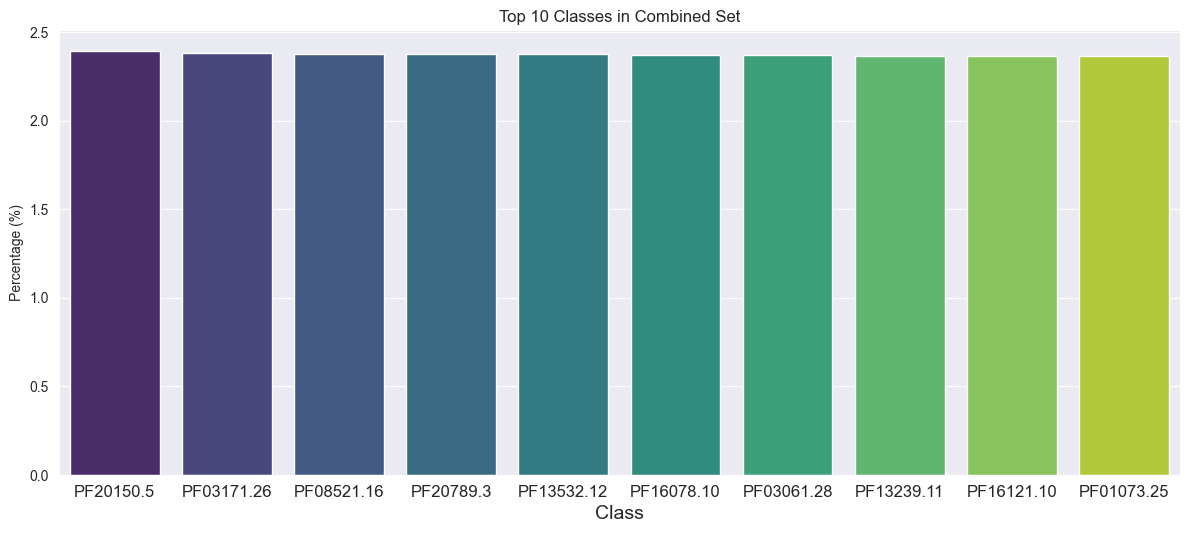

In [16]:
# plot percentage of top 10 classes in train, val, test and combined 
def plot_top_classes(df, split_name, top_n=10):
    # Get class counts
    class_counts = df['label'].value_counts().head(top_n)
    
    # Calculate percentages
    total_count = df.shape[0]
    percentages = (class_counts / total_count) * 100
    
    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=percentages.index, y=percentages.values, palette='viridis')
    plt.xlabel('Class', fontsize=14)
    plt.ylabel('Percentage (%)')
    plt.title(f'Top {top_n} Classes in {split_name} Set')
    plt.xticks(fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    if export:
        plt.savefig(os.path.join(OUTPUT_DIR, f'top_{top_n}_classes_{split_name}_oh.png'))
    plt.show()
    
plot_top_classes(train_df, 'Train')
plot_top_classes(val_df, 'Validation')
plot_top_classes(test_df, 'Test')
plot_top_classes(all_oh_df, 'Combined')

## 4. Obtain Model Predictions and Probabilities (Softmax)
Run inference on train and validation sets for both models. Apply softmax to outputs to get class probabilities.

In [17]:
def get_probs_and_labels(model, loader, device='cuda'):
    model.to(device)
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch['embeddings'].to(device)
            labels = batch['labels'].to(device)
            logits, _ = model(inputs)
            probs = F.softmax(logits, dim=-1)
            # Flatten batch and sequence dims
            all_probs.append(probs.cpu().numpy().reshape(-1, probs.shape[-1]))
            all_labels.append(labels.cpu().numpy().reshape(-1, labels.shape[-1]))
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_probs, all_labels

In [18]:
#combined_dataset_emb = ConcatDataset([train_dataset_emb, val_dataset_emb])
#combined_loader_emb = DataLoader(combined_dataset_emb, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_window)
#
#probs_emb, labels_emb = get_probs_and_labels(model_emb, combined_loader_emb)

## 6. Evaluate Per-Class Metrics (Accuracy, Precision, Recall, F1) on Test Set
Calculate per-class accuracy, precision, recall, and F1-score for both models on the test set using the optimal threshold found from train+val.

In [19]:
probs_oh_test, labels_oh_test = get_probs_and_labels(model_oh, test_loader_oh)
probs_emb_test, labels_emb_test = get_probs_and_labels(model_emb, test_loader_emb)

### Export prediction and targets for later analysis

In [23]:
train_dataset_oh.df.head()

,AC,label,fam_id,fam_id_num,unique_fam_ids,start,end,length,header,sequence
0,A0A8C4TUN5,PF16620.10,PF16620.10,43,58,1092,1243,2714,A0A8C4TUN5|label=PF16620.10-1092-1243|priority...,MVQPVHVLCSQHSPVMHQKLCEHVQTQMSLITGQPPQNSNEIPTVA...
1,A0A2P6TS40,PF23143.1,PF23143.1,58,58,1354,1425,2594,A0A2P6TS40|label=PF23143.1-1354-1425|priority=...,MSGRGGSSSPRRGRPDSGGSGGGKAPDLPPGIGFGPSPRAPLPPNP...
2,A0A0G4KQQ1,PF13532.12,PF13532.12,34,58,557,733,2495,A0A0G4KQQ1|label=PF13532.12-557-733|priority=1...,MATITELDAHEQPSEEMRASWKGYSKLEAFHLRNHPDIDDPRSEGQ...
3,A0A812W5X7,PF00725.27,PF00725.27,4,58,1395,1440,2368,A0A812W5X7|label=PF00725.27-1395-1440|priority...,MVISTSSREFAFLELFAGCAGFSGAVKRVNAESVRVLEPLDDGNGW...
4,A0A1Q9DM40,PF00244.26,PF00244.26,2,58,492,716,2361,A0A1Q9DM40|label=PF00244.26-492-716|priority=1638,MPPREKDVYFAKLAEQAERYDEMADHMKNAGNADSELSVEERNLLS...


In [24]:
train_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates()

,label,fam_id_num
0,PF16620.10,43
1,PF23143.1,58
2,PF13532.12,34
3,PF00725.27,4
4,PF00244.26,2
6,PF12578.13,31
39,PF16121.10,41
65,PF16078.10,40
75,PF22951.1,57
422,PF06439.18,18


In [26]:
labels_and_indices_train = train_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates() 
labels_and_indices_val = val_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates()
labels_and_indices_test = test_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates()

# concat the three dataframes and drop duplicates
labels_and_indices = pd.concat([labels_and_indices_train, labels_and_indices_val, labels_and_indices_test]).drop_duplicates()

In [43]:
def get_label_for_index(index: int) -> str:
    """Get the label for a given index from the labels_and_indices dataframe."""
    try:
        index = int(index)  # Ensure index is an integer
    except ValueError:
        print(f"Invalid index: {index}. Returning original index.")
        return str(index)
    _labels_and_indices_train = train_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates() 
    _labels_and_indices_val = val_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates()
    _labels_and_indices_test = test_dataset_oh.df[['label', 'fam_id_num']].drop_duplicates()
    
    # concat the three dataframes and drop duplicates
    _labels_and_indices = pd.concat([_labels_and_indices_train, _labels_and_indices_val, _labels_and_indices_test]).drop_duplicates()
    if index not in _labels_and_indices['fam_id_num'].values:
        print(f"Index {index} not found in labels_and_indices. Replacing with original index.")
        return str(index)
    return _labels_and_indices.loc[_labels_and_indices['fam_id_num'] == index, 'label'].values[0]

In [44]:
get_label_for_index("2")

'PF00244.26'

In [21]:
import pandas as pd
export_dir = f"{OUTPUT_DIR}/export"
import shutil

if export:
    if not os.path.exists(export_dir):
        os.makedirs(export_dir)

    pd.DataFrame(labels_oh_test).to_csv(f"{export_dir}/labels_onehot.csv", index=False)
    pd.DataFrame(probs_oh_test).to_csv(f"{export_dir}/predictions_onehot.csv", index=False)
    pd.DataFrame(labels_emb_test).to_csv(f"{export_dir}/labels_embeddings.csv", index=False)
    pd.DataFrame(probs_emb_test).to_csv(f"{export_dir}/predictions_embeddings.csv", index=False)

    # zip the export directory and delete original files
    shutil.make_archive(export_dir, 'zip', export_dir)
    # remove the original export directory
    #shutil.rmtree(export_dir)

'C:\\Users\\danei\\OneDrive\\workspace\\ProteinPrediction\\src\\output_rerun_ce_0.5\\export.zip'

In [47]:
# removed threshold from here, as we leave it out
def per_class_metrics(probs, labels):
    y_true = labels.argmax(axis=-1).flatten()
    y_pred = probs.argmax(axis=-1)
    #mask = probs.max(axis=-1) >= threshold
    #y_pred_thr = np.where(mask, y_pred, -1)
    #valid = y_pred_thr != -1
    report = classification_report(y_true, y_pred, output_dict=True)
    return report

report_oh_test = per_class_metrics(probs_oh_test, labels_oh_test)
report_emb_test = per_class_metrics(probs_emb_test, labels_emb_test)

report_oh_test_df = pd.DataFrame(report_oh_test).T
report_emb_test_df = pd.DataFrame(report_emb_test).T

# assign labels
report_oh_test_df["label"] = report_oh_test_df.index.map(get_label_for_index)
report_emb_test_df["label"] = report_emb_test_df.index.map(get_label_for_index)

C:\miniconda\envs\ProteinPrediction\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\miniconda\envs\ProteinPrediction\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\miniconda\envs\ProteinPrediction\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\

Index 0 not found in labels_and_indices. Replacing with original index.
Invalid index: accuracy. Returning original index.
Invalid index: macro avg. Returning original index.
Invalid index: weighted avg. Returning original index.
Index 0 not found in labels_and_indices. Replacing with original index.
Invalid index: accuracy. Returning original index.
Invalid index: macro avg. Returning original index.
Invalid index: weighted avg. Returning original index.


In [48]:
print("Model1 (OneHot) Test classification report:")
display(report_oh_test_df)
print("Model2 (Embedding) Test classification report:")
display(report_emb_test_df)

Model1 (OneHot) Test classification report:


,precision,recall,f1-score,support,label
0,0.733080,0.958058,0.830604,1.022604e+06,0
1,0.953210,0.446848,0.608460,9.802000e+03,PF00198.28
2,0.397295,0.097446,0.156506,1.296100e+04,PF00244.26
3,0.049356,0.017544,0.025886,1.311000e+03,PF00389.36
4,0.000000,0.000000,0.000000,6.632000e+03,PF00725.27
5,0.865752,0.043689,0.083180,3.321200e+04,PF00803.23
6,0.781797,0.512526,0.619152,1.045800e+04,PF01073.25
7,0.468713,0.083509,0.141760,4.754000e+03,PF01257.25
8,0.532633,0.160723,0.246934,1.609600e+04,PF02737.24
9,0.000000,0.000000,0.000000,0.000000e+00,PF02826.25


Model2 (Embedding) Test classification report:


,precision,recall,f1-score,support,label
0,0.993030,0.986892,0.989951,4.694108e+06,0
1,0.909610,0.969968,0.938820,9.856000e+03,PF00198.28
2,0.358565,0.667744,0.466584,1.299600e+04,PF00244.26
3,0.280429,0.612075,0.384634,1.325000e+03,PF00389.36
4,1.000000,0.002552,0.005091,6.661000e+03,PF00725.27
5,0.881355,0.941037,0.910219,3.336000e+04,PF00803.23
6,0.988952,0.985854,0.987401,1.053300e+04,PF01073.25
7,0.683984,0.696279,0.690077,4.784000e+03,PF01257.25
8,0.726433,0.694978,0.710358,1.618900e+04,PF02737.24
9,0.000000,0.000000,0.000000,0.000000e+00,PF02826.25


In [49]:
## Export classification reports to Excel
export = True
if export:
    report_oh_test_df.to_excel(os.path.join(OUTPUT_DIR, "model_oh_classification_report.xlsx"))
    report_emb_test_df.to_excel(os.path.join(OUTPUT_DIR, "model_emb_classification_report.xlsx"))
export = False

In [8]:
# scatter plot f1 vs. support for both models

# rerun for 0.5 ce, expected higher macro f1 and lower accuracy, class 0 f1 lower, but rest higher

# why not 60% seq id instead of 30%

# residual per class percentage vs background

# look into macro f1

C:\miniconda\envs\ProteinPrediction\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\miniconda\envs\ProteinPrediction\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\miniconda\envs\ProteinPrediction\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\

Model1 (OneHot) Test classification report:


,precision,recall,f1-score,support
0,0.777236,0.915798,0.840847,1.022604e+06
1,0.921694,0.486329,0.636704,9.802000e+03
2,0.392166,0.431834,0.411045,1.296100e+04
3,0.037383,0.003051,0.005642,1.311000e+03
4,0.000000,0.000000,0.000000,6.632000e+03
5,0.832017,0.399524,0.539829,3.321200e+04
6,0.895143,0.697935,0.784333,1.045800e+04
7,0.531773,0.167228,0.254441,4.754000e+03
8,0.650000,0.004038,0.008027,1.609600e+04
9,0.000000,0.000000,0.000000,0.000000e+00


Model2 (Embedding) Test classification report:


,precision,recall,f1-score,support
0,0.987407,0.993936,0.990661,4.694108e+06
1,0.968652,0.906047,0.936304,9.856000e+03
2,0.404175,0.032779,0.060641,1.299600e+04
3,0.117647,0.001509,0.002981,1.325000e+03
4,0.000000,0.000000,0.000000,6.661000e+03
5,0.897046,0.923801,0.910227,3.336000e+04
6,0.992868,0.978069,0.985413,1.053300e+04
7,0.713967,0.601589,0.652978,4.784000e+03
8,0.686972,0.948792,0.796929,1.618900e+04
9,0.000000,0.000000,0.000000,0.000000e+00


- Precision: For each class, precision is the proportion of predicted positives that are actually correct. High precision means few false positives.
- Recall: For each class, recall is the proportion of actual positives that are correctly identified. High recall means few false negatives.
- F1-score: The harmonic mean of precision and recall for each class. It balances both metrics; high only if both precision and recall are high.
- Support: The number of true instances for each class in the dataset (how many times each class appears).

On the y-axis are all classes for which the model predicted something - seeing UndefinedMetricWarning means that the model didnt predict some classes.

In [52]:
report_oh_test_df

,precision,recall,f1-score,support,label
0,0.733080,0.958058,0.830604,1.022604e+06,0
1,0.953210,0.446848,0.608460,9.802000e+03,PF00198.28
2,0.397295,0.097446,0.156506,1.296100e+04,PF00244.26
3,0.049356,0.017544,0.025886,1.311000e+03,PF00389.36
4,0.000000,0.000000,0.000000,6.632000e+03,PF00725.27
5,0.865752,0.043689,0.083180,3.321200e+04,PF00803.23
6,0.781797,0.512526,0.619152,1.045800e+04,PF01073.25
7,0.468713,0.083509,0.141760,4.754000e+03,PF01257.25
8,0.532633,0.160723,0.246934,1.609600e+04,PF02737.24
9,0.000000,0.000000,0.000000,0.000000e+00,PF02826.25


In [60]:
# Scatter plot F1 vs. support for both models
def plot_f1_vs_support(report_df, model_name):
    # exclude index 0 (background) from the plot
    report_df = report_df[report_df.index != '0']
    # exclude accuracy and macro avg rows
    report_df = report_df[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    
    plt.figure(figsize=(10, 6))
    ax = sns.scatterplot(data=report_df, x='support', y='f1-score', palette='viridis', s=100)
    ax.set_xscale('log')
    plt.title(f'{model_name} - F1 Score vs Support (log scale)')
    plt.xlabel('Support (Number of True Instances, log scale)')
    plt.ylabel('F1 Score')
    plt.axhline(y=0.0, color='r', linestyle='--', label='F1 = 0.0')
    # plt.legend()
    export = True
    if export:
        plt.savefig(os.path.join(OUTPUT_DIR, f'f1_vs_support_{model_name}_log.png'))
    plt.show()

C:\Users\danei\AppData\Local\Temp\ipykernel_31980\3343312814.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.scatterplot(data=report_df, x='support', y='f1-score', palette='viridis', s=100)


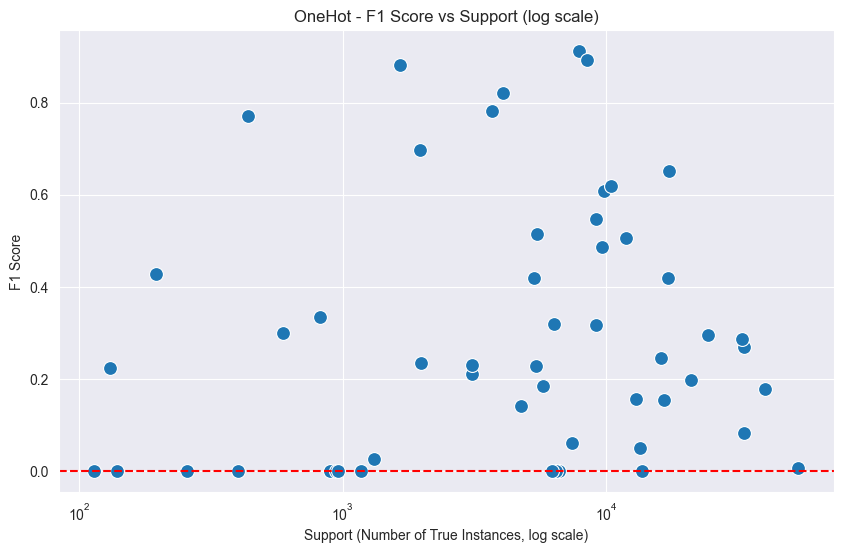

In [61]:
plot_f1_vs_support(report_oh_test_df, 'OneHot')

C:\Users\danei\AppData\Local\Temp\ipykernel_31980\3343312814.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.scatterplot(data=report_df, x='support', y='f1-score', palette='viridis', s=100)


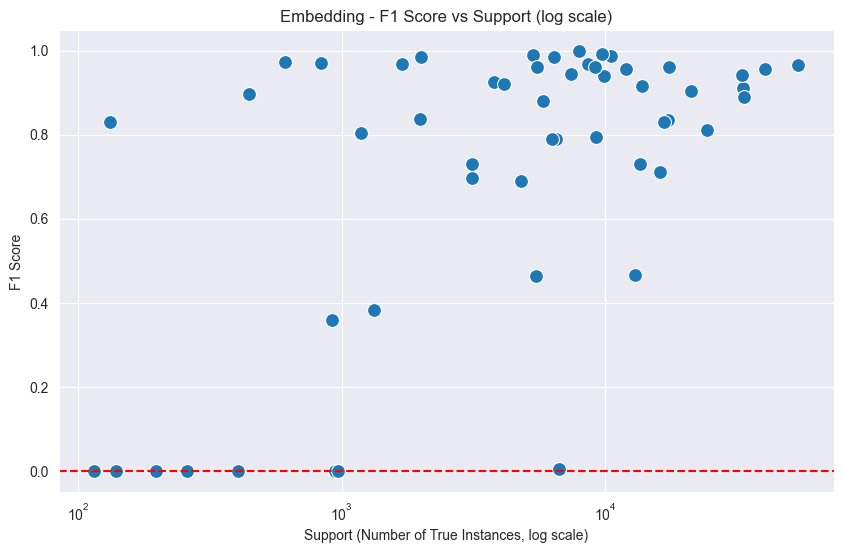

In [62]:
plot_f1_vs_support(report_emb_test_df, 'Embedding')

### Residual per class percentage vs background

In [70]:
# combine datasets to get the residual per class percentage vs background
train_df = train_dataset_oh.df
val_df = val_dataset_oh.df
test_df = test_dataset_oh.df
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

In [78]:
domain_vs_background = (
    combined_df[["label", "fam_id_num", "start", "end", "length"]]
    .assign(domain_length=lambda _df: _df["end"] - _df["start"])
    # .assign(domain_vs_background=lambda _df: _df.apply(lambda row: (row["end"] - row["start"]) / row["length"], axis=1))
    .groupby("label")
    [["domain_length", "length"]]
    .sum()
    .assign(
        domain_vs_background=lambda _df: _df["domain_length"] / _df["length"],
        background=lambda _df: 1 - _df["domain_vs_background"]
    ).sort_values(by="domain_vs_background", ascending=True)
    #.to_excel(os.path.join(OUTPUT_DIR, "residual_per_class_vs_background.xlsx"), index=True, header=True, float_format="%.4f")
)

In [79]:
report_oh_test_df.columns

Index(['precision', 'recall', 'f1-score', 'support', 'label'], dtype='object')

In [80]:
# merge with classification report
report = (
    domain_vs_background
    .merge(report_oh_test_df, how="left", on="label")
    .merge(report_emb_test_df, how="left", on="label", suffixes=('_oh', '_emb'))
)

In [82]:
report.head()

,label,domain_length,length,domain_vs_background,background,precision_oh,recall_oh,f1-score_oh,support_oh,precision_emb,recall_emb,f1-score_emb,support_emb
0,PF16078.10,38473,988131,0.038935,0.961065,0.969685,0.656672,0.783057,3702.0,0.965975,0.886243,0.924393,3780.0
1,PF23143.1,68677,1164930,0.058954,0.941046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PF08793.15,1872,27759,0.067438,0.932562,0.705882,0.000876,0.001749,13703.0,0.887416,0.943886,0.914780,13829.0
3,PF17947.6,46759,641527,0.072887,0.927113,0.666667,0.223844,0.335155,822.0,0.942373,1.000000,0.970332,834.0
4,PF16620.10,89319,1141089,0.078275,0.921725,0.940541,0.190831,0.317287,9118.0,0.947962,0.971959,0.959810,9165.0


In [86]:
report.dropna(how="any", axis="rows")

,label,domain_length,length,domain_vs_background,background,precision_oh,recall_oh,f1-score_oh,support_oh,precision_emb,recall_emb,f1-score_emb,support_emb
0,PF16078.10,38473,988131,0.038935,0.961065,0.969685,0.656672,0.783057,3702.0,0.965975,0.886243,0.924393,3780.0
2,PF08793.15,1872,27759,0.067438,0.932562,0.705882,0.000876,0.001749,13703.0,0.887416,0.943886,0.914780,13829.0
3,PF17947.6,46759,641527,0.072887,0.927113,0.666667,0.223844,0.335155,822.0,0.942373,1.000000,0.970332,834.0
4,PF16620.10,89319,1141089,0.078275,0.921725,0.940541,0.190831,0.317287,9118.0,0.947962,0.971959,0.959810,9165.0
5,PF22951.1,97403,1215071,0.080162,0.919838,0.949596,0.722290,0.820491,4069.0,0.883586,0.960019,0.920218,4127.0
6,PF18321.7,42402,324547,0.130650,0.869350,0.805668,0.003715,0.007397,53561.0,0.966131,0.965827,0.965979,54078.0
7,PF10417.14,34637,215860,0.160460,0.839540,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
8,PF16121.10,45133,271200,0.166420,0.833580,0.883229,0.575294,0.696754,1959.0,0.976399,0.732423,0.836994,1977.0
9,PF12578.13,119054,693120,0.171765,0.828235,0.903588,0.880919,0.892110,8490.0,0.967185,0.971126,0.969151,8589.0
10,PF00725.27,85013,471494,0.180306,0.819694,0.000000,0.000000,0.000000,6632.0,1.000000,0.002552,0.005091,6661.0


In [87]:
# plot scatter plot of domain_vs_background vs f1-score for both models
def plot_domain_vs_background(report_df: pd.DataFrame, model_name):
    # clean df
    report_df = report_df.dropna(how="any", axis="rows")
    full_model_name = f"Model: OneHot" if model_name == 'oh' else f"Model: Embedding"
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=report_df, x='domain_vs_background', y=f'f1-score_{model_name}', s=100)
    plt.axhline(y=0.0, color='r', linestyle='--', label='F1 = 0.0')
    plt.xlabel('Domain vs Background Ratio')
    plt.ylabel(f'F1 Score ({full_model_name})')
    plt.title(f'Domain vs Background Ratio vs F1 Score ({full_model_name})')
    export = True
    if export:
        plt.savefig(os.path.join(OUTPUT_DIR, f'domain_vs_background_vs_f1_{model_name}.png'))
    plt.show()

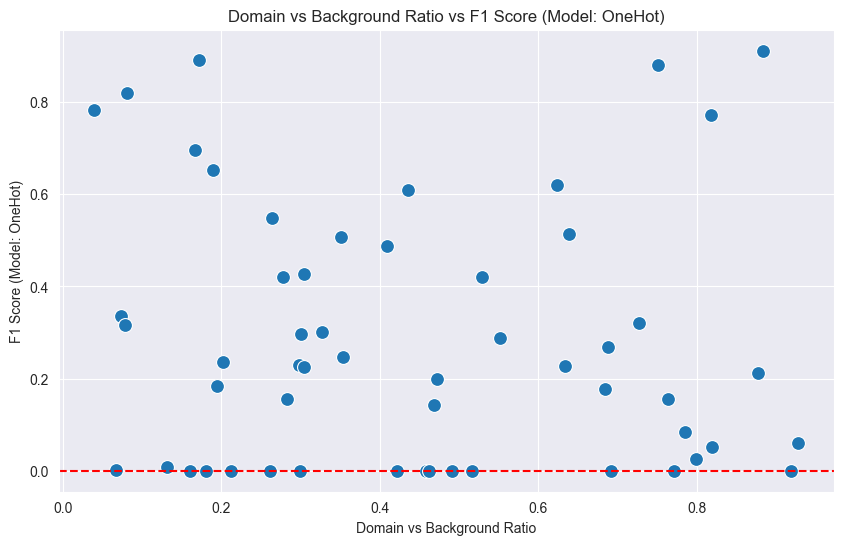

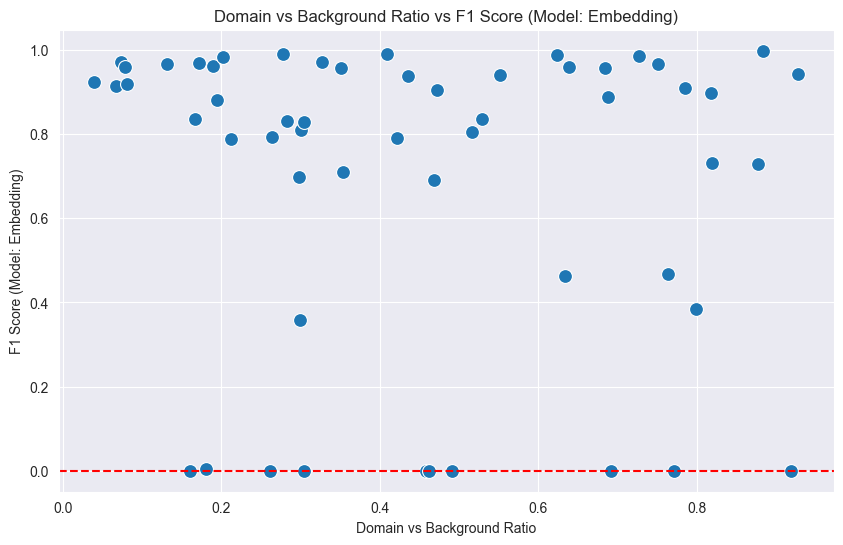

In [88]:
plot_domain_vs_background(report, 'oh')
plot_domain_vs_background(report, 'emb')

In [91]:
combined_df.groupby(["label", "fam_id_num"])[["length"]].mean()

,,length
label,fam_id_num,
PF00198.28,1,508.336745
PF00244.26,2,252.796296
PF00389.36,3,379.976116
PF00725.27,4,516.989035
PF00803.23,5,289.277778
PF01073.25,6,374.349239
PF01257.25,7,282.498474
PF02737.24,8,494.739130
PF02826.25,9,375.268795


In [93]:
report = report.merge(
    combined_df.groupby(["label", "fam_id_num"])[["length"]].mean().rename(columns={"length": "avg_length"}),
    how="left", 
    on="label"
)

In [94]:
# scatter plot avg_length vs f1-score for both models
def plot_avg_length_vs_f1(report_df: pd.DataFrame, model_name):
    # clean df
    report_df = report_df.dropna(how="any", axis="rows")
    full_model_name = f"Model: OneHot" if model_name == 'oh' else f"Model: Embedding"
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=report_df, x='avg_length', y=f'f1-score_{model_name}', s=100)
    plt.axhline(y=0.0, color='r', linestyle='--', label='F1 = 0.0')
    plt.xlabel('Average Length of Domain')
    plt.ylabel(f'F1 Score ({full_model_name})')
    plt.title(f'Average Length of Domain vs F1 Score ({full_model_name})')
    export = True
    if export:
        plt.savefig(os.path.join(OUTPUT_DIR, f'avg_length_vs_f1_{model_name}.png'))
    plt.show()

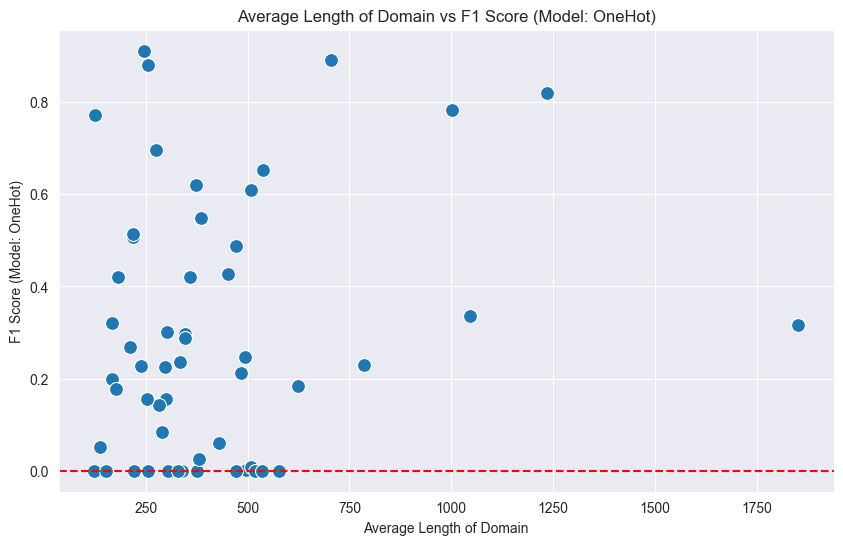

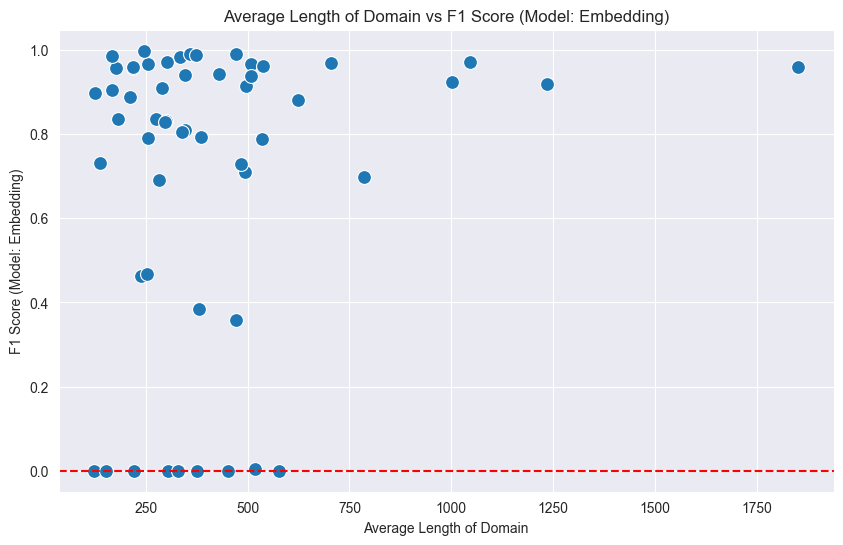

In [95]:
plot_avg_length_vs_f1(report, 'oh')
plot_avg_length_vs_f1(report, 'emb')

## 7. Test Set Evaluation: Predictions and Metrics
Run inference on the test set for both models. Compute accuracy, precision, recall, F1-score (macro), and confusion matrix at the residue level.

In [63]:
def test_metrics(probs, labels):
    y_true = labels.argmax(axis=-1).flatten()
    y_pred = probs.argmax(axis=-1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, prec, rec, f1, cm

acc_oh, prec_oh, rec_oh, f1_oh, cm_oh = test_metrics(probs_oh_test, labels_oh_test)
acc_emb, prec_emb, rec_emb, f1_emb, cm_emb = test_metrics(probs_emb_test, labels_emb_test)
print(f"Model1 (OneHot) Test - Acc: {acc_oh:.4f}, Prec: {prec_oh:.4f}, Rec: {rec_oh:.4f}, F1: {f1_oh:.4f}")
print(f"Model2 (Embedding) Test - Acc: {acc_emb:.4f}, Prec: {prec_emb:.4f}, Rec: {rec_emb:.4f}, F1: {f1_emb:.4f}")

Model1 (OneHot) Test - Acc: 0.7104, Prec: 0.5170, Rec: 0.2527, F1: 0.2954
Model2 (Embedding) Test - Acc: 0.9776, Prec: 0.7117, Rec: 0.7248, F1: 0.6998


## 8. Measure Inference Runtime and GPU Usage
Measure inference time using time.perf_counter() and GPU memory usage with tracemalloc.get_traced_memory() for both models on the test set.

In [11]:
def measure_inference_time_and_memory(model, loader, device='cuda'):
    model.to(device)
    tracemalloc.start()
    start = time.perf_counter()
    with torch.no_grad():
        for batch in loader:
            inputs = batch['embeddings'].to(device)
            logits, _ = model(inputs)
            _ = F.softmax(logits, dim=-1)
    end = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return end - start, peak / 1e6  # seconds, MB

time_oh, mem_oh = measure_inference_time_and_memory(model_oh, test_loader_oh)
time_emb, mem_emb = measure_inference_time_and_memory(model_emb, test_loader_emb)
print(f"Model1 (OneHot) inference time: {time_oh:.2f}s, peak memory: {mem_oh:.2f}MB")
print(f"Model2 (Embedding) inference time: {time_emb:.2f}s, peak memory: {mem_emb:.2f}MB")

Model1 (OneHot) inference time: 20.32s, peak memory: 0.19MB
Model2 (Embedding) inference time: 13.92s, peak memory: 9.81MB


## 9. Calculate Model Size (Number of Parameters)
Count and display the number of trainable parameters for each model.

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model1 (OneHot) parameters: {count_parameters(model_oh):,}")
print(f"Model2 (Embedding) parameters: {count_parameters(model_emb):,}")

Model1 (OneHot) parameters: 7,943,226
Model2 (Embedding) parameters: 9,483,834


## 10. Compute Confusion Matrix for Residue-Level Predictions
Plot and analyze confusion matrices for residue-level predictions for both models.

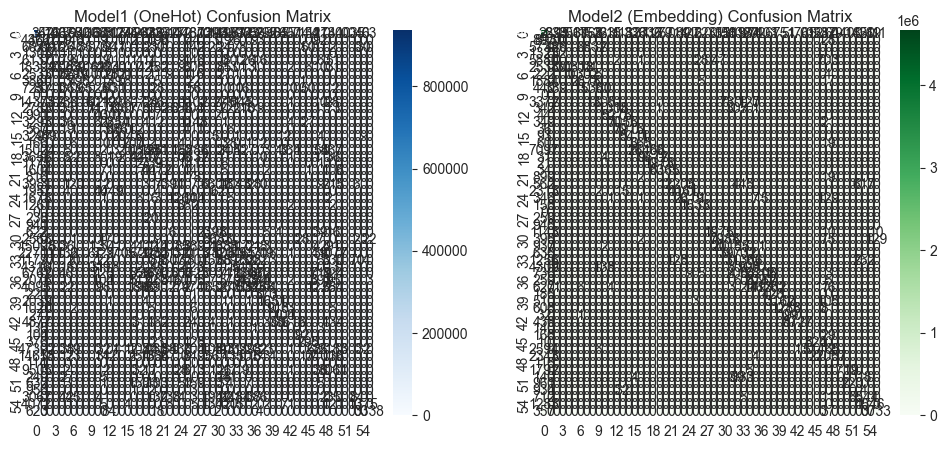

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_oh, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Model1 (OneHot) Confusion Matrix')
sns.heatmap(cm_emb, annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Model2 (Embedding) Confusion Matrix')
plt.show()

## 11. Domain-Level Prediction Evaluation
Compare predicted domains with annotated domains in the test set and evaluate domain-level accuracy. This typically involves grouping residue-level predictions into domains and comparing them to annotated domain boundaries.

**Suggestions:**
- Define a function to extract domains from residue-level predictions (e.g., consecutive residues with the same label).
- Compare predicted domains to true domains using overlap, Jaccard index, or boundary accuracy.
- Compute domain-level precision, recall, and F1-score.

In [14]:
def extract_domains(labels, min_length=2):
    """Extract domain regions from a sequence of labels.
    Only keep domains of length >= min_length.
    Returns a list of (label, start, end) tuples.
    """
    domains = []
    current_label = None
    start = 0
    for i, label in enumerate(labels):
        if label != current_label:
            if current_label is not None:
                if i - start >= min_length:
                    domains.append((current_label, start, i-1))
            current_label = label
            start = i
    # Add last domain
    if len(labels) - start >= min_length:
        domains.append((current_label, start, len(labels)-1))
    return domains

In [16]:
# Convert one-hot/probabilities to class indices for the whole sequence
y_true_seq = labels_oh_test.argmax(axis=-1)  
y_pred_seq = probs_oh_test.argmax(axis=-1)   

y_true_seq_emb = labels_emb_test.argmax(axis=-1)  
y_pred_seq_emb = probs_emb_test.argmax(axis=-1)   

# Extract domains from the entire sequence
min_length = 2
true_domains = extract_domains(y_true_seq, min_length=min_length)
pred_domains = extract_domains(y_pred_seq, min_length=min_length)
print("OneHot Model Domains:")
print(f"Extracted {len( true_domains)} true domains with {min_length} :", true_domains) 
print(f"Extracted {len( pred_domains)} predicted domains with {min_length}:", pred_domains)

# Extract domains from the embedding model
true_domains_emb = extract_domains(y_true_seq_emb, min_length=min_length)
pred_domains_emb = extract_domains(y_pred_seq_emb, min_length=min_length)
print("Embedding Model Domains:")
print(f"Extracted {len(true_domains_emb)} true domains with {min_length} :", true_domains_emb)
print(f"Extracted {len(pred_domains_emb)} predicted domains with {min_length}:", pred_domains_emb)

OneHot Model Domains:
Extracted 8212 true domains with 2 : [(0, 0, 1156), (17, 1157, 1330), (0, 1331, 6724), (5, 6725, 6993), (0, 6994, 8769), (15, 8770, 8842), (0, 8843, 11890), (25, 11891, 11926), (0, 11927, 17896), (17, 17897, 18113), (0, 18114, 21506), (56, 21507, 21579), (0, 21580, 25283), (17, 25284, 25465), (0, 25466, 28584), (55, 28585, 28709), (0, 28710, 31394), (38, 31395, 31484), (0, 31485, 35933), (17, 35934, 36107), (0, 36108, 38931), (34, 38932, 39094), (0, 39095, 44603), (36, 44604, 44699), (0, 44700, 47415), (55, 47416, 47548), (0, 47549, 52335), (17, 52336, 52506), (0, 52507, 54491), (57, 54492, 54564), (0, 54565, 58387), (13, 58388, 58535), (0, 58536, 62294), (55, 62295, 62457), (0, 62458, 66167), (57, 66168, 66237), (0, 66238, 70693), (57, 70694, 70763), (0, 70764, 73984), (17, 73985, 74217), (0, 74218, 77887), (17, 77888, 78053), (0, 78054, 83013), (37, 83014, 83111), (0, 83112, 85620), (57, 85621, 85686), (0, 85687, 90090), (2, 90091, 90623), (0, 90624, 93588), (37

## 12. Analyze Confusion Patterns Between Protein Families
Compute and visualize confusion matrices for actual vs predicted protein families. Analyze common confusion patterns.

**Suggestions:**
- Ensure your dataset includes a family label for each protein.
- Aggregate predictions at the protein level (e.g., majority vote or max probability for each protein).
- Compute a confusion matrix using true and predicted family labels.
- Visualize the confusion matrix and highlight common confusions.

In [ ]:
# Example structure for family-level confusion matrix
# Assume you have lists: true_families, pred_families (one per protein)
from sklearn.metrics import confusion_matrix

# true_families = [...]  # List of true family labels for each protein
# pred_families = [...]  # List of predicted family labels for each protein
# family_names = [...]   # List of all family names (for axis labels)

# cm_family = confusion_matrix(true_families, pred_families, labels=family_names)
# plt.figure(figsize=(8,6))
# sns.heatmap(cm_family, annot=True, fmt='d', xticklabels=family_names, yticklabels=family_names, cmap='Purples')
# plt.xlabel('Predicted Family')
# plt.ylabel('True Family')
# plt.title('Family-level Confusion Matrix')
# plt.show()

print("Family-level confusion analysis: Fill true_families and pred_families, then use the above code to visualize and analyze confusion patterns.")

To save the model to html with cell outputs run 'jupyter nbconvert --to html EVAL_ProteinModel_Comparison.ipynb'